In [25]:
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
import pdb

In [26]:
def magsum(magss):
    return -2.5*np.log10(np.sum(10**(-0.4*magss)))

In [27]:
def calc_blends(l,b,blend_rad=0.36/3600, maglim=18, nonsd=False):
    dat0 = pd.read_hdf(f'outputfiles/vvv_kacz/blend/Huston2025_l{l:.3f}_b{b:.3f}.h5')
    if nonsd:
        dat0 = dat0[dat0['pop']!=2.0]
    dat0.reset_index(drop=True,inplace=True)
    all_blends = np.zeros(len(dat0))
    dat_all = dat0.copy()
    dat_all.reset_index(inplace=True,names='orig_idx')
    all_l, all_b = dat_all['l'].to_numpy(), dat_all['b'].to_numpy()
    delta_l_cosb = ((all_l-360*(all_l>180))-l)*np.cos(all_b*np.pi/180)
    delta_b = all_b-b
    mags = dat_all['VISTA_Ks'].to_numpy()
    mmin, mmax = np.floor(np.min(mags)), np.ceil(np.max(mags))
    
    blend_mags = []
    mlim = mmin
    pbar = tqdm(total=len(dat_all), position=0, leave=True)
    while len(dat_all)>0:
        # re-set arrays
        mags = dat_all['VISTA_Ks'].to_numpy()
        all_l, all_b = dat_all['l'].to_numpy(), dat_all['b'].to_numpy()
        delta_l_cosb = ((all_l-360*(all_l>180))-l)*np.cos(all_b*np.pi/180)
        delta_b = all_b-b
        all_pts = np.transpose([all_l,all_b])
        kdt = KDTree(all_pts)

        # do the thing
        dmag = 0.5
        mlim = mlim + dmag
        bstars = np.where(mags<mlim)[0]
        all_qbp=[]
        if len(bstars)>0:
            qbp = kdt.query_ball_point(all_pts[bstars], blend_rad)
            all_qbp = np.concatenate(qbp)
            while len(np.unique(all_qbp)) != len(all_qbp):
                dmag = dmag/2
                mlim = mlim-dmag
                bstars = np.where(mags<mlim)[0]
                if len(bstars)==0:
                    all_qbp=[]
                    continue
                qbp = kdt.query_ball_point(all_pts[bstars], blend_rad)
                all_qbp = np.concatenate(qbp)
            for i,b in enumerate(bstars):
                bmag = magsum(mags[qbp[i]])
                blend_mags.append(bmag)
                all_blends[(dat_all['orig_idx'][qbp[i]])] = bmag
            dat_all.drop(index=all_qbp, inplace=True)
            dat_all.reset_index(inplace=True, drop=True)
        pbar.update(len(all_qbp))
    return sum(dat0['VISTA_Ks']<maglim), sum(np.array(blend_mags)<maglim), blend_mags, all_blends

In [15]:
cts_in = []
cts_out = []
blends_uni = []
blends_all = []
for b in np.arange(-10.0, 5.0, 1.0)+0.5: 
    for l in np.arange(-4.0, 4.0, 1.0)+0.5:
        print(l,b)
        ct_in,ct_out,blend_uni,blend_mag = calc_blends(l,b)
        cts_in.append(ct_in)
        cts_out.append(ct_out)
        blends_uni.append(blend_uni)
        blends_all.append(blend_mag)

-3.5 -9.5


  0%|          | 0/298261 [00:00<?, ?it/s]

-2.5 -9.5


  0%|          | 0/314932 [00:00<?, ?it/s]

-1.5 -9.5


...

  0%|          | 0/290097 [00:00<?, ?it/s]

2.5 4.5


  0%|          | 0/285900 [00:00<?, ?it/s]

3.5 4.5


  0%|          | 0/276677 [00:00<?, ?it/s]

In [18]:
ls,bs = [],[]
for b in np.arange(-10.0, 5.0, 1.0)+0.5: 
    for l in np.arange(-4.0, 4.0, 1.0)+0.5:
        ls.append(l)
        bs.append(b)
rat = np.array(cts_out)/np.array(cts_in)

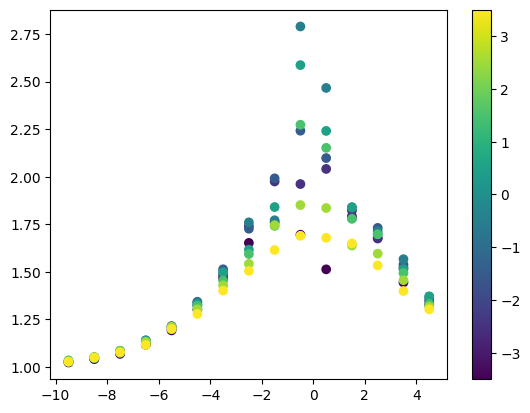

In [26]:
plt.scatter(bs, rat, c=ls)
plt.colorbar()

In [22]:
rats = pd.DataFrame({'l':ls, 'b':bs, 'out_in_ratio':rat})

In [23]:
rats.to_csv('vvv_blends.txt')

In [28]:
cts_in = []
cts_out = []
blends_uni = []
blends_all = []
for b in np.arange(-10.0, 5.0, 1.0)+0.5: 
    for l in np.arange(-4.0, 4.0, 1.0)+0.5:
        print(l,b)
        ct_in,ct_out,blend_uni,blend_mag = calc_blends(l,b,nonsd=True)
        cts_in.append(ct_in)
        cts_out.append(ct_out)
        blends_uni.append(blend_uni)
        blends_all.append(blend_mag)

-3.5 -9.5


  0%|          | 0/298261 [00:00<?, ?it/s]

-2.5 -9.5


  0%|          | 0/314932 [00:00<?, ?it/s]

-1.5 -9.5


...

  0%|          | 0/290097 [00:00<?, ?it/s]

2.5 4.5


  0%|          | 0/285900 [00:00<?, ?it/s]

3.5 4.5


  0%|          | 0/276677 [00:00<?, ?it/s]

In [29]:
ls,bs = [],[]
for b in np.arange(-10.0, 5.0, 1.0)+0.5: 
    for l in np.arange(-4.0, 4.0, 1.0)+0.5:
        ls.append(l)
        bs.append(b)
rat = np.array(cts_out)/np.array(cts_in)

rats = pd.DataFrame({'l':ls, 'b':bs, 'out_in_ratio':rat})
rats.to_csv('vvv_blends_NONSD.txt')

In [20]:
nnsd = pd.read_csv('mulens_rates_vvv_NONSD_mag17.txt')
reg = pd.read_csv('mulens_rates_vvv_tElim_mag17.txt')
nnsd

,l,b,n_source,n_lens,sa_source,sa_lens,avg_tau,avg_murel,avg_theta,eventrate_area,...,frac_bulge_lens,frac_disk_lens,frac_bulge_source,frac_disk_source,n_compact_obj,frac_compact_obj,frac_lowmass,field_id,f_src,f_lens
0,-9.875,-9.875,4102,16265,0.000015,7.743375e-07,6.050746e-08,8.111509,0.833402,0.025171,...,0.232735,0.761425,0.608528,0.385676,1604,0.134504,0.053270,0,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l-...
1,-9.625,-9.875,6337,15309,0.000022,7.143278e-07,6.024405e-08,10.866343,0.884171,0.027654,...,0.217721,0.775430,0.571423,0.422784,1478,0.135514,0.070583,1,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l-...
2,-9.375,-9.875,6372,15455,0.000022,6.997062e-07,7.007927e-08,11.896750,1.296294,0.030140,...,0.218019,0.775012,0.586653,0.408687,1522,0.169771,0.052659,2,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l-...
3,-9.125,-9.875,6204,15616,0.000021,6.792968e-07,6.438783e-08,7.898236,0.817918,0.028707,...,0.269551,0.718815,0.655424,0.339378,1560,0.166027,0.058465,3,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l-...
4,-8.875,-9.875,6098,15645,0.000021,6.524905e-07,6.675282e-08,9.185735,0.826831,0.030359,...,0.267394,0.726262,0.643447,0.353926,1480,0.150652,0.062410,4,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,8.875,4.875,4572,14282,0.000003,8.142424e-08,3.691079e-07,6.184900,0.458830,1.203427,...,0.636562,0.361396,0.860507,0.137258,1328,0.124191,0.065030,4795,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l8...
4796,9.125,4.875,4905,14332,0.000003,8.553657e-08,3.502611e-07,5.975987,0.444375,1.157183,...,0.628601,0.370099,0.854570,0.144072,1368,0.136448,0.073382,4796,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l9...
4797,9.375,4.875,4712,14008,0.000003,8.952706e-08,3.366671e-07,6.329023,0.495147,1.031056,...,0.603166,0.395878,0.847234,0.151490,1347,0.146457,0.069738,4797,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l9...
4798,9.625,4.875,4776,14465,0.000003,9.586310e-08,3.262541e-07,6.348294,0.484937,0.995075,...,0.607387,0.390058,0.843230,0.156642,1289,0.138375,0.060791,4798,outputfiles/vvv_kacz/src18_no_nsd/Huston2025_l...,outputfiles/vvv_kacz/lens_no_nsd/Huston2025_l9...


In [22]:
nnsd = nnsd[(nnsd['l'])==0.125]
reg = reg[(reg['l'])==0.125]

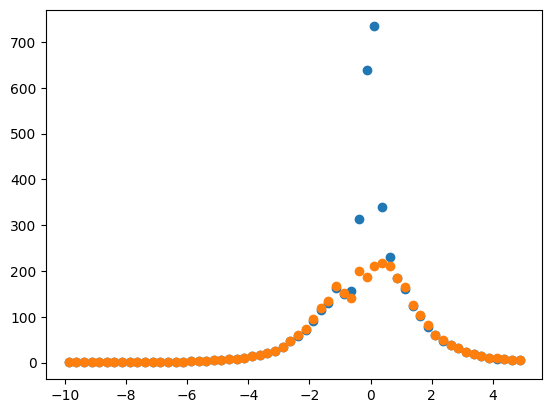

In [23]:
plt.scatter(reg['b'],reg['eventrate_area'])
plt.scatter(nnsd['b'],nnsd['eventrate_area'])